Project: Validating a Rainfall Onset Rule with CHIRPS Daily Rainfall Data for Ibadan (2021–2023)

Does this rainfall onset rule hold up on real rainfall data from Ibadan?

In [20]:
# Install the libraries used in this notebook
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob

In [21]:
# Gather the NetCDF files into one list
files = sorted(glob.glob("*.nc"))

In [22]:
# Check how many files were found
print(f"Number of files combined: {len(files)}")


Number of files combined: 12


In [23]:
import sys; print(sys.executable)
import sys
import subprocess

# This uses your exact path to install the complete dask suite
subprocess.check_call([sys.executable, "-m", "pip", "install", "dask[complete]"])


C:\Users\MY PC\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe


0

In [24]:
# Open the combined dataset with xarray
ds = xr.open_mfdataset(files, combine='by_coords')

# Check the merged dataset
print(ds)

<xarray.Dataset> Size: 21GB
Dimensions:    (time: 366, latitude: 2000, longitude: 7200)
Coordinates:
  * time       (time) datetime64[ns] 3kB 2021-03-01 2021-03-02 ... 2023-06-30
  * latitude   (latitude) float32 8kB -49.97 -49.92 -49.88 ... 49.87 49.92 49.97
  * longitude  (longitude) float32 29kB -180.0 -179.9 -179.9 ... 179.9 180.0
Data variables:
    precip     (time, latitude, longitude) float32 21GB dask.array<chunksize=(3, 250, 900), meta=np.ndarray>
Attributes: (12/15)
    Conventions:       CF-1.6
    title:             CHIRPS Version 2.0
    history:           created by Climate Hazards Group
    version:           Version 2.0
    date_created:      2021-04-28
    creator_name:      Pete Peterson
    ...                ...
    reference:         Funk, C.C., Peterson, P.J., Landsfeld, M.F., Pedreros,...
    comments:           time variable denotes the # of days since 1980-01-01 
    acknowledgements:  The Climate Hazards Group InfraRed Precipitation with ...
    ftp_url:     

In [25]:
# Inspect coordinates and data variables
print(ds.coords)
print(ds.data_vars)

Coordinates:
  * time       (time) datetime64[ns] 3kB 2021-03-01 2021-03-02 ... 2023-06-30
  * latitude   (latitude) float32 8kB -49.97 -49.92 -49.88 ... 49.87 49.92 49.97
  * longitude  (longitude) float32 29kB -180.0 -179.9 -179.9 ... 179.9 180.0
Data variables:
    precip   (time, latitude, longitude) float32 21GB dask.array<chunksize=(3, 250, 900), meta=np.ndarray>


In [26]:
# Ibadan, Nigeria coordinates
lat = 7.3775
lon = 3.9470

In [27]:
# Extract the nearest grid point for Ibadan using the coordinates above
ibadan = ds.sel(
    latitude=lat,
    longitude=lon,
    method="nearest"
)

In [28]:
# Convert the extracted data to a DataFrame and sort by time
df = ibadan.to_dataframe().reset_index()
df = df.sort_values("time")

In [29]:
# Preview the first five rows
df.head()

,time,precip,latitude,longitude
0,2021-03-01,0.0,7.375,3.925003
1,2021-03-02,0.0,7.375,3.925003
2,2021-03-03,0.0,7.375,3.925003
3,2021-03-04,0.0,7.375,3.925003
4,2021-03-05,0.0,7.375,3.925003


In [30]:
# Check for missing values in each column
missing_values = df.isnull().sum()
print(missing_values)

time         0
precip       0
latitude     0
longitude    0
dtype: int64


<Axes: title={'center': 'Precipitation Data for Ibadan, Nigeria'}>

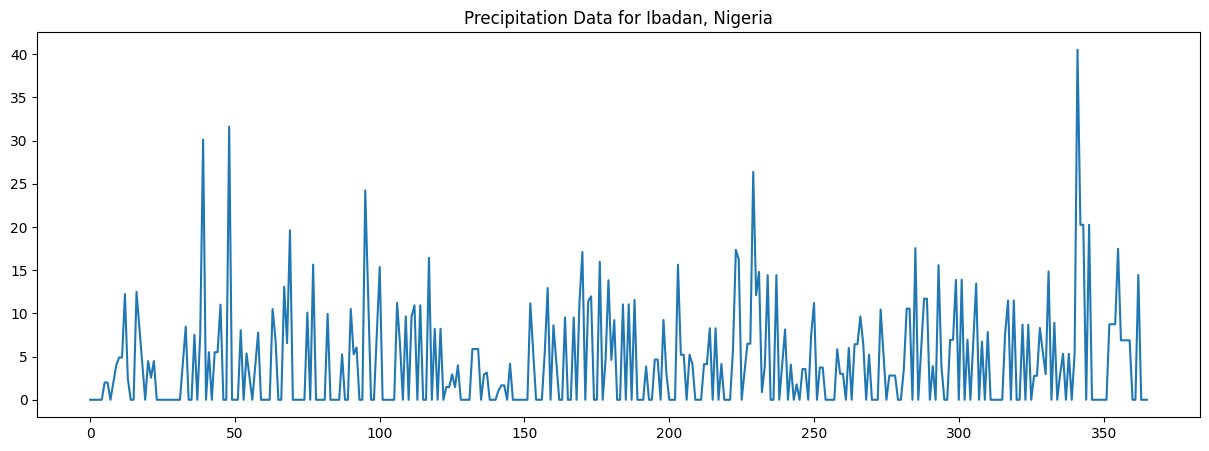

In [31]:
# Plot precipitation for Ibadan
df["precip"].plot(figsize=(15, 5), title="Precipitation Data for Ibadan, Nigeria")

In [32]:
# Check the time range covered by the data
print(df["time"].min())
print(df["time"].max())

2021-03-01 00:00:00
2023-06-30 00:00:00


In [33]:
# Create a quick summary of the rainfall data and export it to Excel

records = len(df)
mean_rainfall = df["precip"].mean()
max_rainfall = df["precip"].max()
missing_values = df["precip"].isnull().sum()

print("Records:", records)
print("Mean Rainfall:", mean_rainfall)
print("Maximum Rainfall:", max_rainfall)
print("Missing Values:", missing_values)

summary_table = pd.DataFrame({
    "Statistic": ["Records", "Mean Rainfall", "Maximum Rainfall", "Missing Values"],
    "Value": [records, mean_rainfall, max_rainfall, missing_values]
})
print(summary_table)

subprocess.check_call([sys.executable, "-m", "pip", "install", "openpyxl"])

summary_table.to_excel(
    "table1_summary_statistics.xlsx",
    index=False
)

Records: 366
Mean Rainfall: 4.2853365
Maximum Rainfall: 40.504288
Missing Values: 0
          Statistic       Value
0           Records  366.000000
1     Mean Rainfall    4.285336
2  Maximum Rainfall   40.504288
3    Missing Values    0.000000


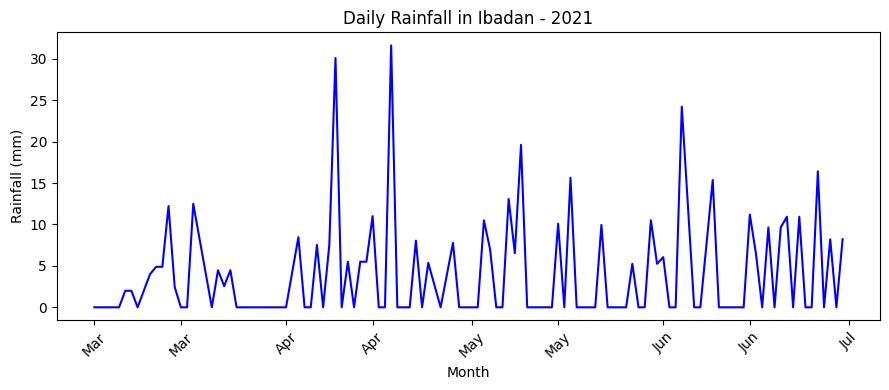

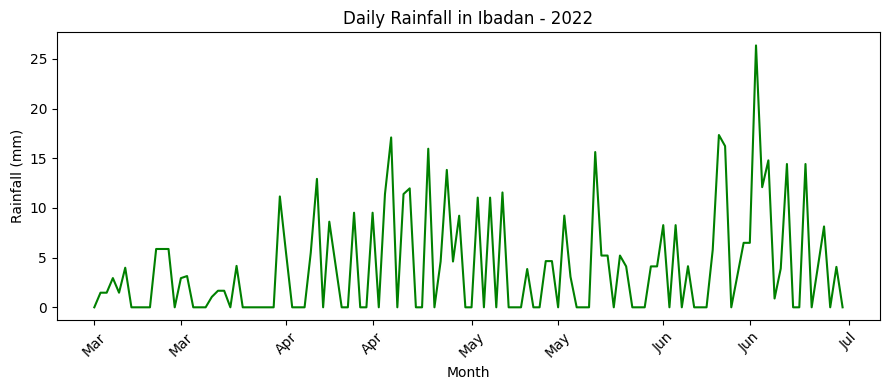

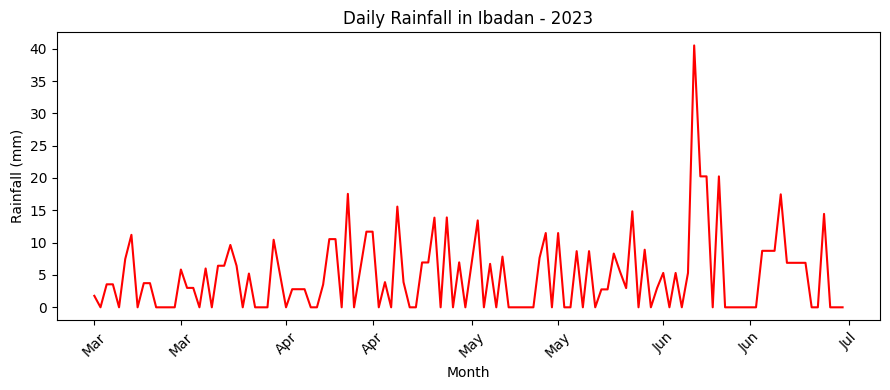

In [34]:
colors = {'2021': 'blue', '2022': 'green', '2023': 'red'}

for year in [2021, 2022, 2023]:
    df_year = df[df['time'].dt.year == year]
    
    plt.figure(figsize=(9, 4))
    plt.plot(df_year['time'], df_year['precip'], color=colors[str(year)])
    plt.title(f'Daily Rainfall in Ibadan - {year}')
    plt.xlabel('Month')
    plt.ylabel('Rainfall (mm)')
    
    # Format x-axis to show months
    plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b'))
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

In [35]:
# Set up the 3-day rolling rainfall total
# Rainfall >= 20 mm
df["year"] = df["time"].dt.year
df["rain_3day"] = (df["precip"].rolling(3).sum()
)

In [36]:
# Find the first onset candidate in each year
results = []

for year in df["year"].unique():
    temp = df[df["year"] == year]
    onset = temp[temp["rain_3day"] >= 20]
    if len(onset) > 0:
        onset_date = onset.iloc[0]["time"]
        results.append({
            "Year": year,
            "Onset Date": onset_date
        })

In [37]:
# Save the onset dates to Excel
onset_table = pd.DataFrame(results)
print(onset_table)

onset_table.to_excel("onset_dates.xlsx", index=False)

   Year Onset Date
0  2021 2021-03-13
1  2022 2022-04-08
2  2023 2023-03-23


 Year Onset Date  Rain Next 10 Days (mm)  Max Dry Days Genuine Onset?
 2021 2021-03-13               46.700001             2          ✅ Yes
 2022 2022-04-08               43.400002             2          ✅ Yes
 2023 2023-03-23               37.000000             3          ✅ Yes


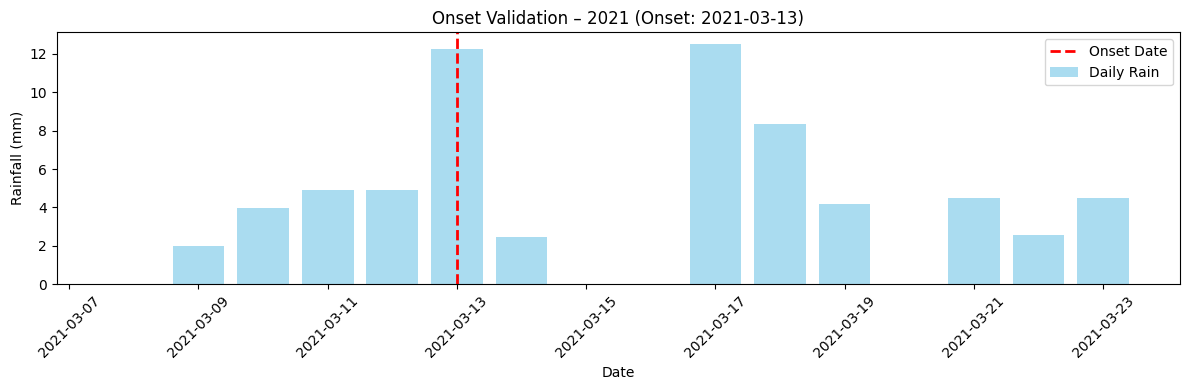

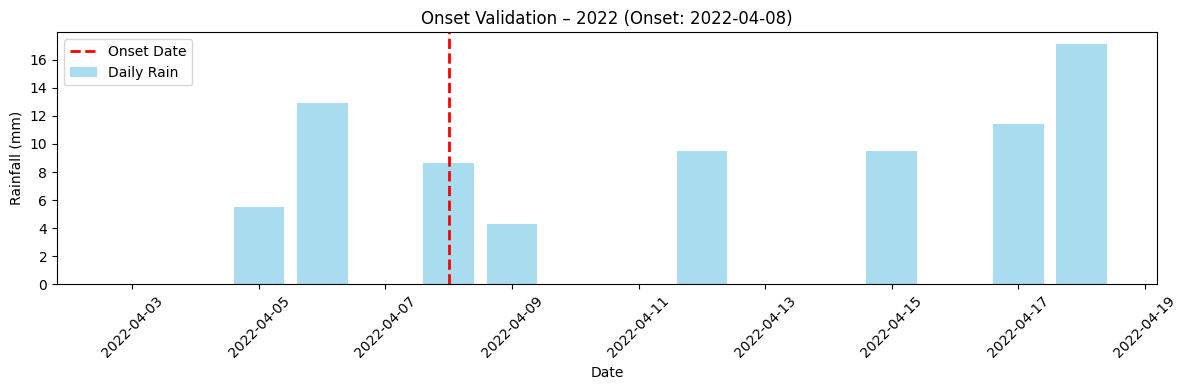

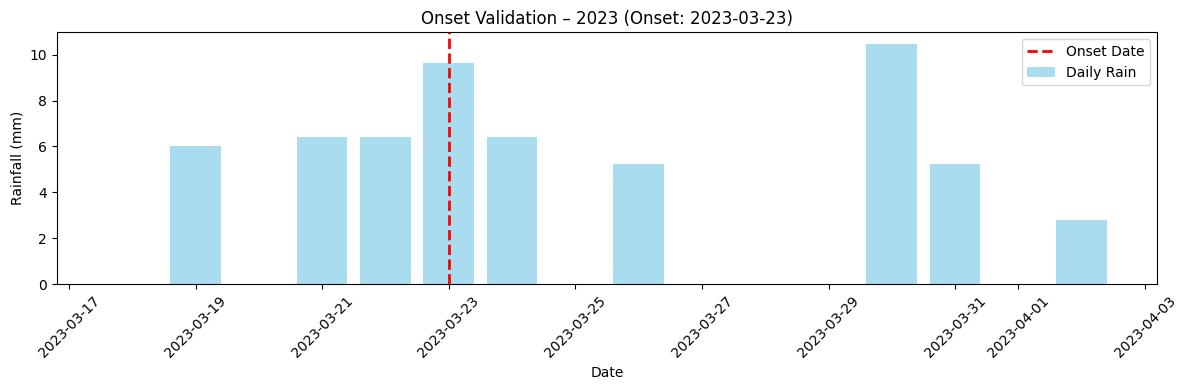


FINAL REPORT: ONSET RULE VALIDATION
Total years analysed: 3
Genuine onsets: 3
False onsets: 0
Success rate: 100%

Takeaways:
- The 3-day, 20-mm rule produced an onset date for each year in this dataset.
- A short follow-up window helps separate real onset from a false start.
- It would still be worth testing nearby thresholds to see whether they change the result.


In [38]:
# We already have the onset dates from the 3-day rolling sum rule.
# Next, check whether each one is followed by enough rainfall to look genuine.

# Validation settings
DRY_SPELL_WINDOW = 10
DRY_THRESHOLD = 1.0
MAX_ALLOWED_DRY_DAYS = 7

def validate_onset(df, onset_date):
    # Look at the next 10 days
    start = onset_date
    end = onset_date + pd.Timedelta(days=DRY_SPELL_WINDOW)
    window = df[(df['time'] >= start) & (df['time'] < end)].copy()
    if len(window) < DRY_SPELL_WINDOW:
        return None
    
    total_rain = window['precip'].sum()
    
    # Find the longest dry spell in the window
    window['is_dry'] = window['precip'] < DRY_THRESHOLD
    dry_groups = (window['is_dry'] != window['is_dry'].shift()).cumsum()
    dry_spell_lengths = window[window['is_dry']].groupby(dry_groups).size()
    max_dry_days = dry_spell_lengths.max() if not dry_spell_lengths.empty else 0
    
    is_genuine = (total_rain >= 20) and (max_dry_days <= MAX_ALLOWED_DRY_DAYS)
    return {
        'onset_date': onset_date,
        'total_rain_next_10_days': round(total_rain, 1),
        'max_consecutive_dry_days': max_dry_days,
        'is_genuine': is_genuine
    }

# Validate each onset candidate
validated = []
for _, row in onset_table.iterrows():
    year = row['Year']
    onset_date = row['Onset Date']
    df_year = df[df['year'] == year].copy()
    res = validate_onset(df_year, onset_date)
    
    if res is None:
        validated.append({'Year': year, 'Onset Date': onset_date.strftime('%Y-%m-%d'),
                          'Rain Next 10 Days (mm)': 'N/A', 'Max Dry Days': 'N/A',
                          'Genuine Onset?': '⚠️ Insufficient data'})
    else:
        validated.append({'Year': year, 'Onset Date': res['onset_date'].strftime('%Y-%m-%d'),
                          'Rain Next 10 Days (mm)': res['total_rain_next_10_days'],
                          'Max Dry Days': res['max_consecutive_dry_days'],
                          'Genuine Onset?': '✅ Yes' if res['is_genuine'] else '❌ No'})

validation_df = pd.DataFrame(validated)
print(validation_df.to_string(index=False))
validation_df.to_excel("onset_validation_results.xlsx", index=False)

## Plot each onset for visual confirmation
for _, row in onset_table.iterrows():
    year = row['Year']
    onset_date = row['Onset Date']
    start = onset_date - pd.Timedelta(days=5)
    end = onset_date + pd.Timedelta(days=10)
    window = df[(df['time'] >= start) & (df['time'] <= end)]
    
    plt.figure(figsize=(12, 4))
    plt.bar(window['time'], window['precip'], color='skyblue', alpha=0.7, label='Daily Rain')
    plt.axvline(x=onset_date, color='red', linestyle='--', linewidth=2, label='Onset Date')
    plt.title(f'Onset Validation – {year} (Onset: {onset_date.strftime("%Y-%m-%d")})')
    plt.xlabel('Date')
    plt.ylabel('Rainfall (mm)')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Summary report
print("\n" + "="*50)
print("FINAL REPORT: ONSET RULE VALIDATION")
print("="*50)
print(f"Total years analysed: {len(onset_table)}")
genuine = validation_df[validation_df['Genuine Onset?'] == '✅ Yes'].shape[0]
false = validation_df[validation_df['Genuine Onset?'] == '❌ No'].shape[0]
print(f"Genuine onsets: {genuine}")
print(f"False onsets: {false}")
print(f"Success rate: {genuine/(genuine+false)*100:.0f}%")

print("\nTakeaways:")
print("- The 3-day, 20-mm rule produced an onset date for each year in this dataset.")
print("- A short follow-up window helps separate real onset from a false start.")
print("- It would still be worth testing nearby thresholds to see whether they change the result.")